<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **Sistema de detección de enlaces spam**

**Autora:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Proyecto de detección de enlaces spam 

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Instrucciones**

#### **Sistema de detección de enlaces spam**

El objetivo de este proyecto es implementar un sistema que sea capaz de detectar automáticamente si una página web contiene spam o no basándonos en su URL.

</div>

________

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **url_spam.csv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/url_spam.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización (opcional pero recomendable)
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# NLP / procesamiento de texto
import re

# Vectorización
from sklearn.feature_extraction.text import TfidfVectorizer

# División de datos
from sklearn.model_selection import train_test_split

# Modelo (SVM)
from sklearn.svm import SVC

# Métricas
from sklearn.metrics import classification_report

# Optimización (más adelante)
from sklearn.model_selection import GridSearchCV

# Guardado
import joblib

In [2]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR
df = pd.read_csv('../data/raw/url_spam.csv')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
df.sample(10, random_state=42)

,url,is_spam
1376,https://link.morningbrew.com/manage/5z8/oc,True
932,https://www.sciencedaily.com/releases/2019/02/...,False
144,https://www.ft.com/content/eae603a4-a369-4801-...,False
1752,https://thehustle.co/careers/,True
51,https://www.caltech.edu/about/news/natural-flu...,False
414,https://www.dupont.com/products/dupont-tychem-...,False
2306,https://link.theskimm.com/manage/5uz/oc,True
266,https://www.espn.com/racing/nascar/story/_/id/...,False
2705,https://www.cnn.com/2020/06/30/politics/kentuc...,False
2424,https://www.morningbrew.com/daily/refer-a-friend,True


In [3]:
# Obtenemos la dimensión del dataset (número de filas y columnas)
df.shape

# Mostramos información general del dataset (tipos de datos y valores nulos)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   url      2999 non-null   str  
 1   is_spam  2999 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 26.5 KB


In [4]:
# Contamos cuántos registros hay de cada clase (spam vs no spam)
df["is_spam"].value_counts()

is_spam
False    2303
True      696
Name: count, dtype: int64

In [5]:
# Calculamos cuántas URLs están duplicadas en el dataset
df["url"].duplicated().sum()

np.int64(630)

In [6]:
# Filtramos todas las URLs duplicadas (incluyendo la primera aparición) y las ordenamos
duplicados = df[df["url"].duplicated(keep=False)].sort_values("url")

# Mostramos una muestra inicial de los duplicados
duplicados.head(25)

# Mostramos una muestra final de los duplicados
duplicados.tail(25)

,url,is_spam
2245,https://www.voxmedia.com/legal/terms-of-use,True
778,https://www.voxmedia.com/legal/terms-of-use,True
1355,https://www.wework.com/info/the-future-of-work...,False
616,https://www.wework.com/info/the-future-of-work...,False
361,https://www.wsj.com/articles/short-sellers-mad...,False
447,https://www.wsj.com/articles/short-sellers-mad...,False
1489,https://www.wsj.com/articles/unemployment-bene...,False
751,https://www.wsj.com/articles/unemployment-bene...,False
2113,https://www.youtube.com/channel/UCyaN6mg5u8Cjy...,True
1754,https://www.youtube.com/channel/UCyaN6mg5u8Cjy...,True


In [7]:
# Verificamos si las URLs duplicadas tienen etiquetas inconsistentes (más de un valor de is_spam)
df.groupby("url")["is_spam"].nunique().value_counts()

is_spam
1    2369
Name: count, dtype: int64

In [8]:
# Eliminamos URLs duplicadas manteniendo la primera aparición
df = df.drop_duplicates(subset="url").reset_index(drop=True)

# Verificamos que ya no existen URLs duplicadas en el dataset
df["url"].duplicated().sum()

np.int64(0)

In [9]:
df.shape

(2369, 2)

In [10]:
# Contamos cuántos registros hay de cada clase (spam vs no spam)
df["is_spam"].value_counts()

is_spam
False    2125
True      244
Name: count, dtype: int64

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación sobre duplicados**

Se han detectado 630 URLs duplicadas (~21% del dataset).  
Tras el análisis, se ha verificado que todas las URLs repetidas mantienen una única etiqueta (`is_spam`), sin inconsistencias.

Por este motivo, se procede a eliminar los duplicados, ya que no aportan información adicional y podrían sesgar el entrenamiento del modelo.

Tras la eliminación, el dataset queda compuesto por 2369 URLs únicas.

Se mantiene un desbalance en las clases:
- URLs no spam: 2125  
- URLs spam: 244  

Este desbalance deberá tenerse en cuenta durante la evaluación del modelo, utilizando métricas adicionales a accuracy.

</div>

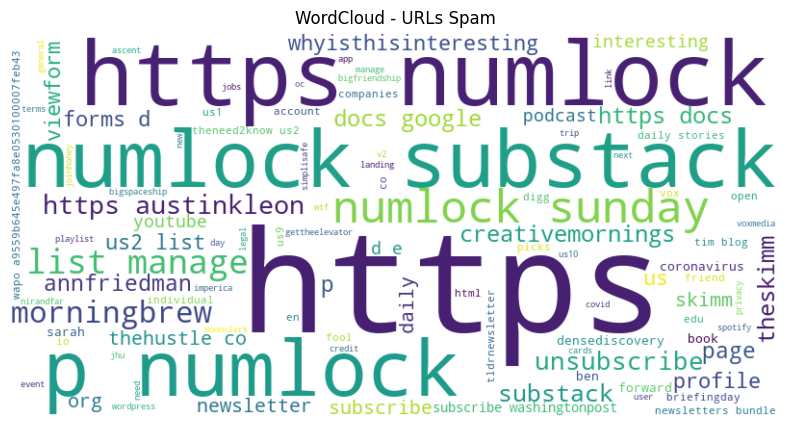

In [ ]:
# Separamos URLs spam y no spam
spam_text = " ".join(df[df["is_spam"] == True]["url"])
no_spam_text = " ".join(df[df["is_spam"] == False]["url"])

# Creamos nube de palabras para URLs spam
wordcloud_spam = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100,
    random_state=42
).generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_spam, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - URLs Spam")
plt.show()

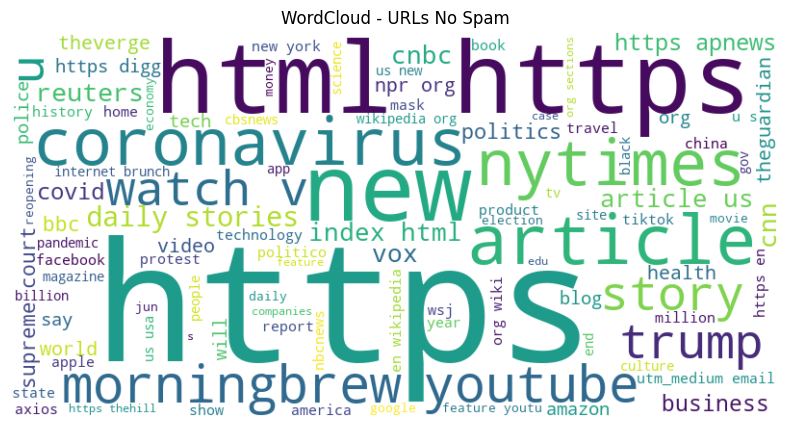

In [32]:
# Creamos nube de palabras para URLs no spam
wordcloud_no_spam = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100,
    random_state=42
).generate(no_spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_no_spam, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - URLs No Spam")
plt.show()

-----

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2: Preprocesa los enlaces**

</div>

In [11]:
def preprocess_url(url):
    # Pasamos a minúsculas
    url = url.lower()
    
    # Separamos por caracteres típicos de URLs
    tokens = re.split(r'[/.?=&:-]', url)
    
    # Eliminamos tokens vacíos
    tokens = [t for t in tokens if t]
    
    return " ".join(tokens)  # OJO: string, no lista porque e slo que espera TfidfVectorizer

df["url"] = df["url"].apply(preprocess_url)

df.head(10)

,url,is_spam
0,https briefingday us8 list manage com unsubscribe,True
1,https www hvper com,True
2,https briefingday com m v4n3i4f3,True
3,https briefingday com n 20200618 m#commentform,False
4,https briefingday com fan,True
5,https www brookings edu interactives reopening...,False
6,https www reuters com investigates special rep...,False
7,https www theatlantic com magazine archive 202...,False
8,https www vox com 2020 6 17 21294680 john bolt...,False
9,https www theguardian com travel 2020 jun 18 e...,False


In [12]:
# Separamos variables predictoras y variable objetivo
X = df["url"]
y = df["is_spam"]

# Dividimos el dataset en entrenamiento y test manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# Convertimos las URLs procesadas en una matriz numérica usando TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=5)

# 2. Fit SOLO en train
X_train_tfidf = vectorizer.fit_transform(X_train)

# 3. Transform en test
X_test_tfidf = vectorizer.transform(X_test)

----

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3: Construye un SVM**

</div>

In [14]:
model_base = SVC(kernel="linear", random_state=42)

# Entrenamos con los datos transformados
model_base.fit(X_train_tfidf, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [15]:
# Generamos las predicciones del modelo sobre el conjunto de test
y_pred = model_base.predict(X_test_tfidf)

In [16]:
# Mostramos métricas completas del modelo
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.94      1.00      0.97       425
        True       0.96      0.47      0.63        49

    accuracy                           0.94       474
   macro avg       0.95      0.73      0.80       474
weighted avg       0.94      0.94      0.93       474



<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación las metricas del modelo base**

El modelo presenta una alta precisión en la clase spam, lo que indica que cuando clasifica una URL como maliciosa suele acertar.

Sin embargo, el recall es bajo, lo que implica que una parte importante de las URLs spam no están siendo detectadas (falsos negativos).

Dado el contexto del problema, es prioritario maximizar el recall de la clase spam, ya que resulta más crítico evitar que URLs maliciosas pasen desapercibidas que bloquear erróneamente algunas URLs legítimas. Por tanto, será necesario ajustar el modelo para mejorar su capacidad de detección, incluso a costa de reducir ligeramente la precisión.

</div>

----

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4: Optimiza el modelo anterior**

</div>

In [17]:
# Definimos un SVM con class_weight="balanced" para compensar el desbalance de clases
model_balanced = SVC(
    kernel="linear",
    class_weight="balanced",
    random_state=42
)

# Entrenamos el modelo con los datos de entrenamiento vectorizados
model_balanced.fit(X_train_tfidf, y_train)

# Realizamos predicciones sobre el conjunto de test
y_pred_balanced = model_balanced.predict(X_test_tfidf)

# Mostramos las métricas de evaluación del modelo balanceado
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

       False       0.97      0.89      0.93       425
        True       0.46      0.78      0.58        49

    accuracy                           0.88       474
   macro avg       0.71      0.83      0.75       474
weighted avg       0.92      0.88      0.89       474



<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación las metricas del modelo balanceado**

Tras aplicar `class_weight="balanced"`, se observa una mejora significativa en el recall de la clase spam (de 0.47 a 0.78), lo que indica que el modelo ahora es capaz de detectar una mayor proporción de URLs maliciosas.

Sin embargo, esta mejora se produce a costa de una reducción en la precisión, lo que implica un aumento en los falsos positivos. Este comportamiento es coherente con el objetivo de priorizar la detección de spam frente a la clasificación conservadora del modelo base.

Dado que el rendimiento del modelo depende en gran medida de la configuración de sus hiperparámetros, el siguiente paso será aplicar técnicas de optimización como Grid Search o Random Search para encontrar la mejor combinación posible que permita mejorar el equilibrio entre precision y recall.

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Elección de GridSearch frente a RandomSearch**

Se ha optado por utilizar GridSearchCV en lugar de RandomSearch debido a que el espacio de hiperparámetros a explorar es reducido y manejable.

En este contexto, GridSearch permite evaluar de forma exhaustiva todas las combinaciones posibles, asegurando la identificación de la mejor configuración del modelo.

Dado el tamaño del dataset y el número limitado de hiperparámetros, el coste computacional es asumible, por lo que no es necesario recurrir a métodos más eficientes pero menos exhaustivos como RandomSearch.

</div>

In [22]:
# Definimos el espacio de hiperparámetros a explorar con GridSearch
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
    "class_weight": [None, "balanced"]
}

# Creamos el GridSearch priorizando f1-score para buscar un equilibrio entre precision y recall
grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Entrenamos el GridSearch con los datos de entrenamiento vectorizados
grid_search.fit(X_train_tfidf, y_train)

# Mostramos los mejores hiperparámetros encontrados
grid_search.best_params_

{'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}

In [21]:
# Guardamos el mejor modelo encontrado por GridSearch
model_grid = grid_search.best_estimator_

# Generamos predicciones con el modelo optimizado
y_pred_grid = model_grid.predict(X_test_tfidf)

# Mostramos las métricas del modelo optimizado
print(classification_report(y_test, y_pred_grid))

              precision    recall  f1-score   support

       False       0.95      0.98      0.97       425
        True       0.79      0.53      0.63        49

    accuracy                           0.94       474
   macro avg       0.87      0.76      0.80       474
weighted avg       0.93      0.94      0.93       474



<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación sobre la optimización con GridSearch**

El modelo optimizado con GridSearch mantiene una accuracy alta (0.94) y mejora la precisión de la clase spam respecto al modelo balanceado.

Sin embargo, el recall de la clase spam queda en 0.53, por debajo del modelo con `class_weight="balanced"` que alcanzaba 0.78.

Esto indica que la optimización de hiperparámetros del SVM no ha mejorado el objetivo principal del problema: detectar la mayor cantidad posible de URLs spam.

Por este motivo, el siguiente paso será revisar la vectorización con TF-IDF, incorporando combinaciones de palabras mediante `ngram_range`, para intentar capturar mejor patrones frecuentes en URLs maliciosas.

</div>

In [23]:
# Creamos una nueva vectorización TF-IDF incorporando unigramas y bigramas
vectorizer_ngram = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    max_df=0.9,
    min_df=2
)

# Ajustamos el vectorizador solo con train y transformamos train/test
X_train_ngram = vectorizer_ngram.fit_transform(X_train)
X_test_ngram = vectorizer_ngram.transform(X_test)

In [24]:
# Entrenamos un SVM balanceado usando la nueva representación TF-IDF con n-grams
model_ngram = SVC(
    kernel="linear",
    class_weight="balanced",
    random_state=42
)

model_ngram.fit(X_train_ngram, y_train)

# Generamos predicciones con el modelo entrenado sobre la nueva vectorización
y_pred_ngram = model_ngram.predict(X_test_ngram)

# Mostramos las métricas del modelo con n-grams
print(classification_report(y_test, y_pred_ngram))

              precision    recall  f1-score   support

       False       0.98      0.92      0.95       425
        True       0.53      0.82      0.64        49

    accuracy                           0.91       474
   macro avg       0.75      0.87      0.79       474
weighted avg       0.93      0.91      0.91       474



<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación impacto de los n-grams**

La incorporación de n-grams (unigramas y bigramas) permite al modelo capturar combinaciones de términos que aportan mayor contexto semántico que las palabras individuales.

Esto resulta especialmente relevante en URLs, donde patrones como "login secure" o "free offer" pueden ser indicadores más claros de contenido malicioso.

Como consecuencia, se observa una mejora significativa en el rendimiento del modelo, especialmente en la detección de la clase spam.

</div>

-----

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 5: Guarda el modelo**

</div>

In [28]:
# Guardamos el modelo final
joblib.dump(model_ngram, "../models/svm_url_spam_model.sav")

# Guardamos el vectorizador TF-IDF
joblib.dump(vectorizer_ngram, "../models/tfidf_vectorizer_ngram.sav")

['../models/tfidf_vectorizer_ngram.sav']

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusión final del proyecto**

A lo largo del proceso de optimización se ha observado claramente el impacto de cada estrategia aplicada sobre el rendimiento del modelo.

- El modelo base presentaba una alta precisión pero un recall muy bajo en la clase spam, lo que implicaba que muchas URLs maliciosas no estaban siendo detectadas.

- Al aplicar balanceo de clases (`class_weight="balanced"`), se logró mejorar significativamente el recall, aunque a costa de una pérdida notable en precisión, evidenciando el trade-off entre ambas métricas.

- Posteriormente, la optimización mediante GridSearch permitió ajustar los hiperparámetros del modelo, recuperando parte del equilibrio entre precisión y recall, pero sin lograr una mejora sustancial en la detección de spam.

- Finalmente, la incorporación de n-grams en la vectorización TF-IDF resultó ser la mejora más efectiva, ya que permitió capturar patrones más complejos en las URLs. Esto se tradujo en un incremento significativo del recall sin degradar excesivamente la precisión, logrando así el mejor equilibrio global del modelo.

Por tanto, se concluye que la representación de los datos (feature engineering) ha tenido un mayor impacto en el rendimiento que el ajuste fino del modelo, siendo la estrategia clave para mejorar la detección de URLs spam.

</div>